## **Parametric optimization and comparative study of machine learning and deep learning algorithms for breast cancer diagnosis**

In [1]:
from ucimlrepo import fetch_ucirepo

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

## 1. Dataset

In [3]:
# Wisconsin Breast Cancer Dataset (Original)
breast_cancer_dataset = fetch_ucirepo(id=15)

In [4]:
breast_cancer_dataset.variables

,name,role,type,demographic,description,units,missing_values
0,Sample_code_number,ID,Categorical,None,NaN,None,no
1,Clump_thickness,Feature,Integer,None,NaN,None,no
2,Uniformity_of_cell_size,Feature,Integer,None,NaN,None,no
3,Uniformity_of_cell_shape,Feature,Integer,None,NaN,None,no
4,Marginal_adhesion,Feature,Integer,None,NaN,None,no
5,Single_epithelial_cell_size,Feature,Integer,None,NaN,None,no
6,Bare_nuclei,Feature,Integer,None,NaN,None,yes
7,Bland_chromatin,Feature,Integer,None,NaN,None,no
8,Normal_nucleoli,Feature,Integer,None,NaN,None,no
9,Mitoses,Feature,Integer,None,NaN,None,no


In [5]:
X = breast_cancer_dataset.data.features
y = breast_cancer_dataset.data.targets

In [6]:
df = X.join(y)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [8]:
df.isnull().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

## 2. Data Preprocessing

### Handling Missing Values

The `Bare_nuclei` feature contains 16 missing observations. These observations are removed before model training.

In [9]:
df.dropna(subset='Bare_nuclei', inplace=True)

**Fig. 2. Correlation matrix.**

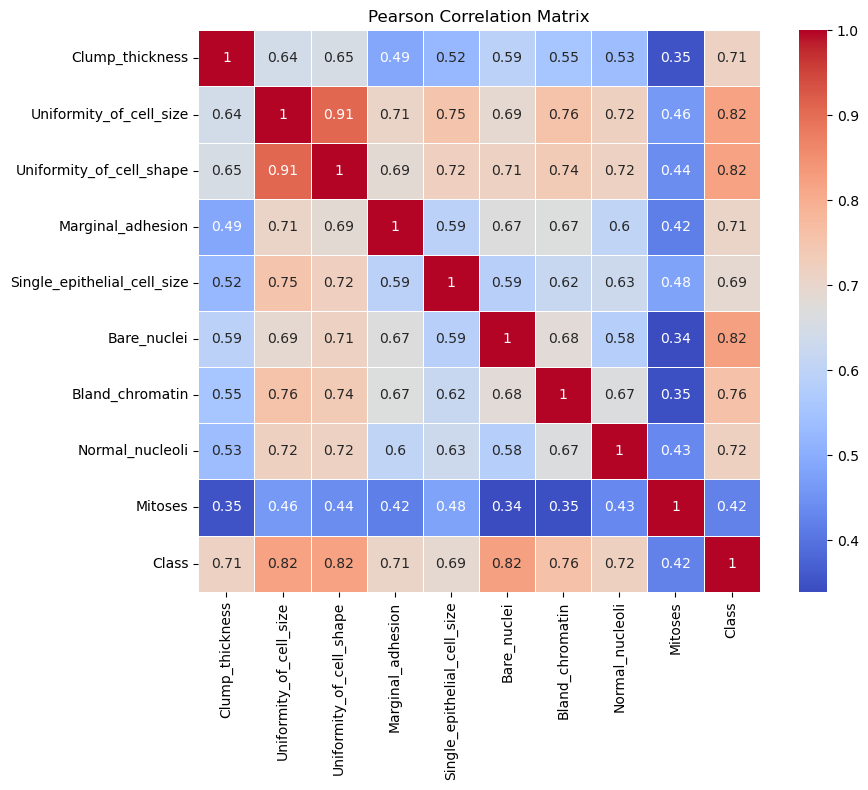

In [10]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(
    "figures/correlation_matrix.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Fig. 3. Data distribution of features.**

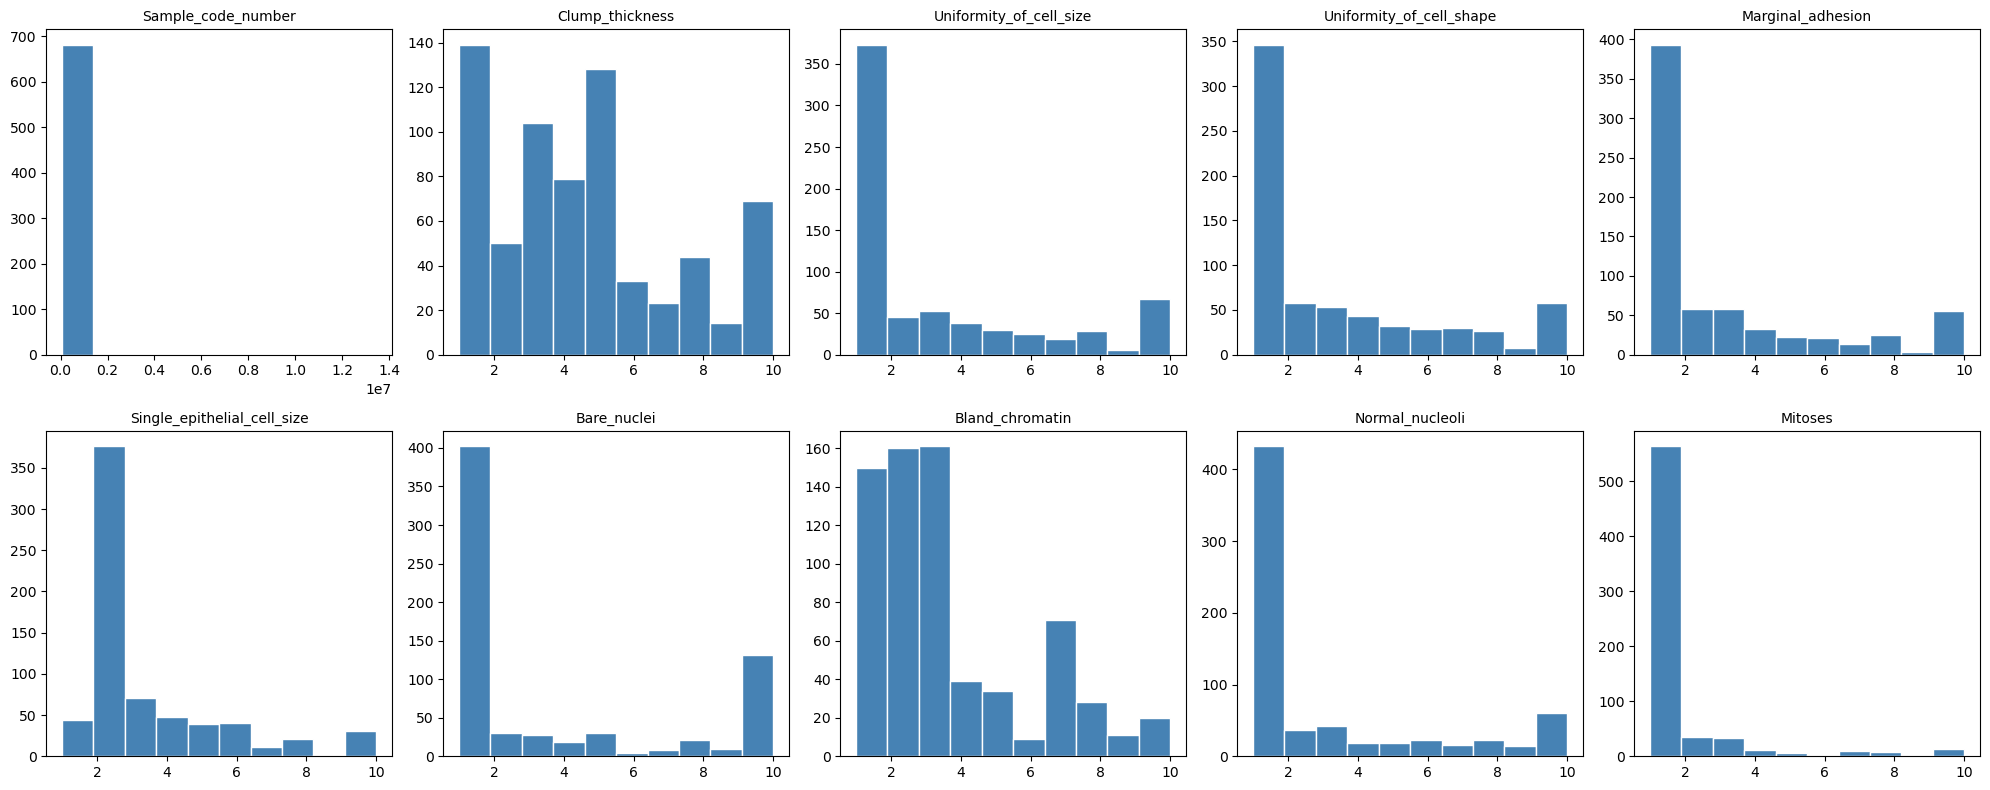

In [11]:
df_fig3 = breast_cancer_dataset.data.ids.join(df.drop(columns=['Class']), how='inner')
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(df_fig3.columns):
    axes[i].hist(df_fig3[col], bins=10, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.savefig(
    "figures/data_distribution.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Feature Selection

1. The correlation matrix indicates a strong correlation between `Uniformity_of_cell_shape` and `Uniformity_of_cell_size`. Following the procedure used in the reference paper, `Uniformity_of_cell_shape` is removed.
2. Consequently, the use of SMOTE was necessitated by the extremely clear class imbalance between benign and malignant tumors and the absence of any additional imputation or processing requirements.

In [12]:
df.drop(columns=['Uniformity_of_cell_shape'], inplace=True)

In [13]:
X = df.drop(columns=['Class'])
y = df['Class']

### Train/Test Split

The dataset is divided into training and test sets using a 70/30 split
with `random_state=9`.

In [14]:
_random_state = 9
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=_random_state)

### Feature Standardization

The input features are standardized using `StandardScaler`. The scaler
is fitted only on the training data and subsequently applied to both
training and test sets.

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Class Balancing with SMOTE

SMOTE is applied only to the training set.

In [17]:
smote = SMOTE(random_state=_random_state)

In [18]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [19]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, auc

I0000 00:00:1788785347.951717   15613 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788785349.769714   15613 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [21]:
class EvaluationMetrics:

	def __init__(self):
		self.evaluation_results_table2 = []
		self.evaluation_results_section33 = []

	def table2(self, model_name, y_test, y_pred):
		self.evaluation_results_table2.append({
			"Model": model_name,
			"Precision (Benign)": precision_score(y_test, y_pred, pos_label=2),
			"Precision (Malignant)": precision_score(y_test, y_pred, pos_label=4),
			"F1 Score (Benign)": f1_score(y_test, y_pred, pos_label=2),
			"F1 Score (Malignant)": f1_score(y_test, y_pred, pos_label=4),
			"Accuracy (%)": accuracy_score(y_test, y_pred) * 100
		})

	def section33(self, model_name, y_test, y_pred):
		self.evaluation_results_section33.append({
			"Model": model_name,
			"Precision (Benign)": precision_score(y_test, y_pred, pos_label=2),
			"Precision (Malignant)": precision_score(y_test, y_pred, pos_label=4),
			"F1 Score (Benign)": f1_score(y_test, y_pred, pos_label=2),
			"F1 Score (Malignant)": f1_score(y_test, y_pred, pos_label=4),
			"Accuracy (%)": accuracy_score(y_test, y_pred) * 100
		})

In [22]:
metrics = EvaluationMetrics()

## 4. Model Training with Table 2 Parameters

The following models are implemented using the hyperparameter configurations reported in **Table 2** of the reference paper.

### 4.1 Logistic Regression

In [23]:
lr2 = LogisticRegression(
    max_iter=3000,
    intercept_scaling=0.5,
    random_state=_random_state
)
lr2.fit(X_train_resampled, y_train_resampled)
y_pred_lr2 = lr2.predict(X_test_scaled)

In [24]:
metrics.table2("Logistic Regression", y_test, y_pred_lr2)

### 4.2 Decision Tree

In [25]:
dt2 = DecisionTreeClassifier(random_state=_random_state)
dt2.fit(X_train_resampled, y_train_resampled)
y_pred_dt2 = dt2.predict(X_test_scaled)

In [26]:
metrics.table2("Decision Tree", y_test, y_pred_dt2)

### 4.3 Decision Tree with Hyperparameter Tuning

In [27]:
dt_ht2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=3,
    min_samples_split=5,
    random_state=_random_state
)
dt_ht2.fit(X_train_resampled, y_train_resampled)
y_pred_dt_ht2 = dt_ht2.predict(X_test_scaled)

In [28]:
metrics.table2("Decision Tree with Hyperparameter Tuning", y_test, y_pred_dt_ht2)

### 4.4 Support vector classifier

In [29]:
svc2 = SVC(
    kernel='rbf',
    probability=True,
    shrinking=False,
    cache_size=300,
    verbose=True,
    random_state=_random_state
)
svc2.fit(X_train_resampled, y_train_resampled)
y_pred_svc2 = svc2.predict(X_test_scaled)

[LibSVM]*
optimization finished, #iter = 140
obj = -37.010046, rho = -0.671145
nSV = 77, nBSV = 37
Total nSV = 77
*
optimization finished, #iter = 117
obj = -38.235999, rho = -0.656456
nSV = 72, nBSV = 39
Total nSV = 72
*
optimization finished, #iter = 135
obj = -41.744472, rho = -0.603331
nSV = 85, nBSV = 41
Total nSV = 85
*
optimization finished, #iter = 113
obj = -43.065983, rho = -0.558713
nSV = 76, nBSV = 43
Total nSV = 76
*
optimization finished, #iter = 116
obj = -42.648690, rho = -0.628516
nSV = 81, nBSV = 44
Total nSV = 81
*
optimization finished, #iter = 144
obj = -49.576210, rho = 0.566797
nSV = 92, nBSV = 49
Total nSV = 92


In [30]:
metrics.table2("Support Vector Classifier", y_test, y_pred_svc2)

### 4.5 Naïve Bayes

In [31]:
nb2 = GaussianNB(var_smoothing=1e-8)
nb2.fit(X_train_resampled, y_train_resampled)
y_pred_nb2 = nb2.predict(X_test_scaled)

In [32]:
metrics.table2("Naïve Bayes", y_test, y_pred_nb2)

### 4.6 KNN

In [33]:
knn2 = KNeighborsClassifier(
    n_neighbors=6,
    weights='distance',
    algorithm='ball_tree',
    metric='manhattan'
)
knn2.fit(X_train_resampled, y_train_resampled)
y_pred_knn2 = knn2.predict(X_test_scaled)

In [34]:
metrics.table2("KNN", y_test, y_pred_knn2)

### 4.7 Random forest classifier

In [35]:
rf2 = RandomForestClassifier(random_state=_random_state)
rf2.fit(X_train_resampled, y_train_resampled)
y_pred_rf2 = rf2.predict(X_test_scaled)

In [36]:
metrics.table2("Random Forest Classifier", y_test, y_pred_rf2)

### 4.8 Random forest classifier with Hyperparameter Tuning

In [37]:
rf_ht2 = RandomForestClassifier(
    bootstrap=True,
    max_depth=3,
    max_features='sqrt', # 'auto' deprecated in newer sklearn
    min_samples_leaf=4,
    min_samples_split=4,
    n_estimators=80,
    random_state=_random_state
)
rf_ht2.fit(X_train_resampled, y_train_resampled)
y_pred_rf_ht2 = rf_ht2.predict(X_test_scaled)

In [38]:
metrics.table2("Random Forest Classifier with Hyperparameter Tuning", y_test, y_pred_rf_ht2)

### 4.9 AdaBoost

In [39]:
ada2 = AdaBoostClassifier(
    # algorithm='SAMME', the keyword argument is depricated and SAMME is the default algorithm
    learning_rate=0.05,
    n_estimators=70,
    random_state=_random_state
)
ada2.fit(X_train_resampled, y_train_resampled)
y_pred_ada2 = ada2.predict(X_test_scaled)

In [40]:
metrics.table2("AdaBoost", y_test, y_pred_ada2)

### 4.10 Gradient Boost

In [41]:
gb2 = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    # criterion='mse', removed in newer sklearn — using default
    random_state=_random_state
)
gb2.fit(X_train_resampled, y_train_resampled)
y_pred_gb2 = gb2.predict(X_test_scaled)

In [42]:
metrics.table2("Gradient Boost", y_test, y_pred_gb2)

### 4.11 LightGBM Classifier with Hyperparameter Tuning

In [43]:
lgbm2 = LGBMClassifier(
    learning_rate=0.05,
    n_estimators=120,
    num_leaves=25,
    random_state=_random_state,
    verbosity=-1
)
lgbm2.fit(X_train_resampled, y_train_resampled)
y_pred_lgbm2 = lgbm2.predict(X_test_scaled)

In [44]:
metrics.table2("LGBM Classifier with Hyperparameter Tuning", y_test, y_pred_lgbm2)

### 4.12 XGBoost

### Label Encoding

The original dataset uses the class labels `2` (benign) and `4` (malignant).
For XGBoost, these labels are mapped to binary labels, where `0` represents
benign observations and `1` represents malignant observations.

In [45]:
y_train_xgb = y_train_resampled.map({2: 0, 4: 1})
y_test_xgb = y_test.map({2: 0, 4: 1})

In [46]:
xgb2 = XGBClassifier(
    learning_rate=0.2,
    max_depth=2,
    n_estimators=60,
    random_state=_random_state
)
xgb2.fit(X_train_resampled, y_train_xgb)
y_pred_xgb2 = xgb2.predict(X_test_scaled)

In [47]:
metrics.evaluation_results_table2.append({
    "Model": "XGBoost",
    "Precision (Benign)": precision_score(y_test_xgb, y_pred_xgb2, pos_label=0),
    "Precision (Malignant)": precision_score(y_test_xgb, y_pred_xgb2, pos_label=1),
    "F1 Score (Benign)": f1_score(y_test_xgb, y_pred_xgb2, pos_label=0),
    "F1 Score (Malignant)": f1_score(y_test_xgb, y_pred_xgb2, pos_label=1),
    "Accuracy (%)": accuracy_score(y_test_xgb, y_pred_xgb2) * 100
})

## 5. Model Training with Table 2 Parameters

The following models are implemented using the hyperparameter configurations reported in **Section 3.3** of the reference paper.

### 5.1 Logistic Regression

In [48]:
lr33 = LogisticRegression(
    max_iter=5000,
    intercept_scaling=0.5,
    random_state=_random_state
)
lr33.fit(X_train_resampled, y_train_resampled)
y_pred_lr33 = lr33.predict(X_test_scaled)

In [49]:
metrics.section33("Logistic Regression", y_test, y_pred_lr33)

### 5.2 Decision Tree

In [50]:
dt33 = DecisionTreeClassifier(random_state=_random_state)
dt33.fit(X_train_resampled, y_train_resampled)
y_pred_dt33 = dt33.predict(X_test_scaled)

In [51]:
metrics.section33("Decision Tree", y_test, y_pred_dt33)

### 5.3 Decision Tree with Hyperparameter Tuning

In [52]:
dt_ht33 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=3,
    random_state=_random_state
)
dt_ht33.fit(X_train_resampled, y_train_resampled)
y_pred_dt_ht33 = dt_ht33.predict(X_test_scaled)

In [53]:
metrics.section33("Decision Tree with Hyperparameter Tuning", y_test, y_pred_dt_ht33)

### 5.4 Support vector classifier

In [54]:
svc33 = SVC(
    kernel='linear',
    probability=True,
    shrinking=False,
    cache_size=300,
    verbose=False,
    random_state=_random_state
)
svc33.fit(X_train_resampled, y_train_resampled)
y_pred_svc33 = svc33.predict(X_test_scaled)

In [55]:
metrics.section33("Support Vector Classifier", y_test, y_pred_svc33)

### 5.5 Naïve Bayes

In [56]:
nb33 = GaussianNB(var_smoothing=2e-9)
nb33.fit(X_train_resampled, y_train_resampled)
y_pred_nb33 = nb33.predict(X_test_scaled)

In [57]:
metrics.section33("Naïve Bayes", y_test, y_pred_nb33)

### 5.6 KNN

In [58]:
knn33 = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    algorithm='ball_tree',
    metric='minkowski'
)
knn33.fit(X_train_resampled, y_train_resampled)
y_pred_knn33 = knn33.predict(X_test_scaled)

In [59]:
metrics.section33("KNN", y_test, y_pred_knn33)

### 5.7 Random forest classifier

In [60]:
rf33 = RandomForestClassifier(random_state=_random_state)
rf33.fit(X_train_resampled, y_train_resampled)
y_pred_rf33 = rf33.predict(X_test_scaled)

In [61]:
metrics.section33("Random Forest Classifier", y_test, y_pred_rf33)

### 5.8 Random forest classifier with Hyperparameter Tuning

In [62]:
rf_ht33 = RandomForestClassifier(
    bootstrap=True,
    max_depth=8,
    max_features='sqrt', # 'auto' deprecated in newer sklearn
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=48,
    random_state=_random_state
)
rf_ht33.fit(X_train_resampled, y_train_resampled)
y_pred_rf_ht33 = rf_ht33.predict(X_test_scaled)

In [63]:
metrics.section33("Random Forest Classifier with Hyperparameter Tuning", y_test, y_pred_rf_ht33)

### 5.9 AdaBoost

In [64]:
ada33 = AdaBoostClassifier(
    # algorithm='SAMME.R', not available in newer sklearn
    learning_rate=0.1,
    n_estimators=200,
    random_state=_random_state
)
ada33.fit(X_train_resampled, y_train_resampled)
y_pred_ada33 = ada33.predict(X_test_scaled)

In [65]:
metrics.section33("AdaBoost", y_test, y_pred_ada33)

### 5.10 Gradient Boost

In [66]:
gb33 = GradientBoostingClassifier(
    learning_rate=0.5,
    n_estimators=100,
    subsample=0.8,
    # criterion='mse', removed in newer sklearn — using default
    random_state=_random_state
)
gb33.fit(X_train_resampled, y_train_resampled)
y_pred_gb33 = gb33.predict(X_test_scaled)

In [67]:
metrics.section33("Gradient Boost", y_test, y_pred_gb33)

### 5.11 LightGBM Classifier with Hyperparameter Tuning

In [68]:
lgbm33 = LGBMClassifier(
    learning_rate=0.05,
    n_estimators=200,
    num_leaves=50,
    random_state=_random_state,
    verbosity=-1
)
lgbm33.fit(X_train_resampled, y_train_resampled)
y_pred_lgbm33 = lgbm33.predict(X_test_scaled)

In [69]:
metrics.section33("LGBM Classifier with Hyperparameter Tuning", y_test, y_pred_lgbm33)

### 5.12 XGBoost

### Label Encoding

The original dataset uses the class labels `2` (benign) and `4` (malignant).
For XGBoost, these labels are mapped to binary labels, where `0` represents
benign observations and `1` represents malignant observations.

In [70]:
y_train_xgb = y_train_resampled.map({2: 0, 4: 1})
y_test_xgb = y_test.map({2: 0, 4: 1})

In [71]:
xgb33 = XGBClassifier(
    learning_rate=0.4,
    max_depth=3,
    n_estimators=175,
    random_state=_random_state
)
xgb33.fit(X_train_resampled, y_train_xgb)
y_pred_xgb33 = xgb33.predict(X_test_scaled)

In [72]:
metrics.evaluation_results_section33.append({
    "Model": "XGBoost",
    "Precision (Benign)": precision_score(y_test_xgb, y_pred_xgb33, pos_label=0),
    "Precision (Malignant)": precision_score(y_test_xgb, y_pred_xgb33, pos_label=1),
    "F1 Score (Benign)": f1_score(y_test_xgb, y_pred_xgb33, pos_label=0),
    "F1 Score (Malignant)": f1_score(y_test_xgb, y_pred_xgb33, pos_label=1),
    "Accuracy (%)": accuracy_score(y_test_xgb, y_pred_xgb33) * 100
})

## 6. Artificial Neural Network

The ANN architecture and training parameters are implemented according to Table 3 of the paper.

#### Label Encoding

The original dataset uses class labels `2` and `4`. For ANN Classifier, these labels are mapped to binary labels `0` and `1`.

In [73]:
y_train_ann = pd.Series(y_train_resampled).map({2: 0, 4: 1}).values
y_test_ann = y_test.map({2: 0, 4: 1}).values

In [74]:
np.random.seed(_random_state)
tf.random.set_seed(_random_state)

ann = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(10, activation='relu'),
    Dropout(0.1),
    Dense(5, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

E0000 00:00:1788785352.912978   15613 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


### ANN Architecture

The neural network consists of:

- Input layer: 8 features
- Hidden layer 1: 10 neurons, ReLU activation
- Dropout: 0.1
- Hidden layer 2: 5 neurons, ReLU activation
- Dropout: 0.1
- Output layer: 1 neuron, sigmoid activation

The network is trained using Adam optimization and binary cross-entropy loss.

In [75]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [76]:
history = ann.fit(
    X_train_resampled, y_train_ann,
    epochs=70,
    batch_size=5,
)

Epoch 1/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9022 - loss: 0.4000
Epoch 2/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9432 - loss: 0.2480
Epoch 3/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9558 - loss: 0.1596
Epoch 4/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9479 - loss: 0.1416
Epoch 5/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9543 - loss: 0.1243
Epoch 6/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9527 - loss: 0.1247
Epoch 7/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9637 - loss: 0.1090
Epoch 8/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9606 - loss: 0.1208
Epoch 9/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9669 - loss: 0.0965
Epoch 10/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9685 - loss: 0.0995
Epoch 11/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9637 - loss: 0.1114
Epoch 12/70
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

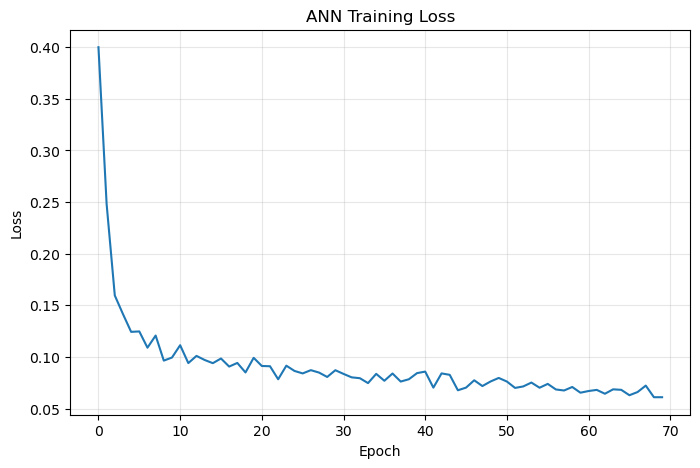

In [77]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training Loss")
plt.grid(alpha=0.3)
plt.savefig(
    "figures/ANN_training_loss.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

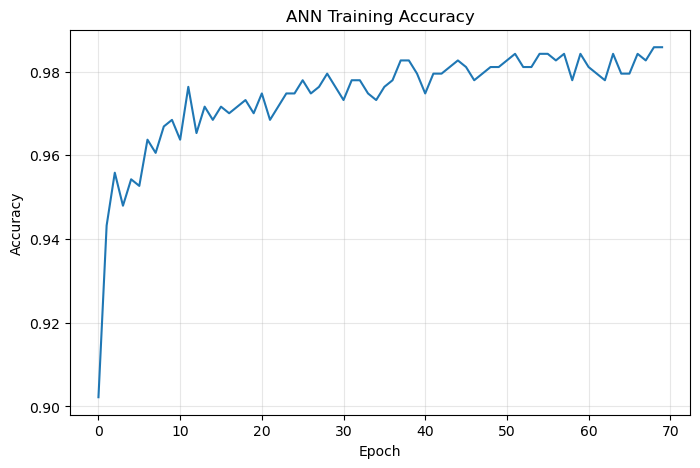

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training Accuracy")
plt.grid(alpha=0.3)
plt.savefig(
    "figures/ANN_training_accuracy.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [79]:
y_pred_ann_prob = ann.predict(X_test_scaled)
y_pred_ann = (y_pred_ann_prob > 0.5).astype(int).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [80]:
metrics.evaluation_results_table2.append({
    "Model": "Artificial Neural Network Classifier",
    "Precision (Benign)": precision_score(y_test_ann, y_pred_ann, pos_label=0),
    "Precision (Malignant)": precision_score(y_test_ann, y_pred_ann, pos_label=1),
    "F1 Score (Benign)": f1_score(y_test_ann, y_pred_ann, pos_label=0),
    "F1 Score (Malignant)": f1_score(y_test_ann, y_pred_ann, pos_label=1),
    "Accuracy (%)": accuracy_score(y_test_ann, y_pred_ann) * 100
})

metrics.evaluation_results_section33.append({
    "Model": "Artificial Neural Network Classifier",
    "Precision (Benign)": precision_score(y_test_ann, y_pred_ann, pos_label=0),
    "Precision (Malignant)": precision_score(y_test_ann, y_pred_ann, pos_label=1),
    "F1 Score (Benign)": f1_score(y_test_ann, y_pred_ann, pos_label=0),
    "F1 Score (Malignant)": f1_score(y_test_ann, y_pred_ann, pos_label=1),
    "Accuracy (%)": accuracy_score(y_test_ann, y_pred_ann) * 100
})

In [81]:
results_df_table2 = pd.DataFrame(metrics.evaluation_results_table2)
results_df_table2.to_csv("results/results_table2.csv", index=False)

In [82]:
results_df_section33 = pd.DataFrame(metrics.evaluation_results_section33)
results_df_section33.to_csv("results/results_section3.3.csv", index=False)

## 7. Comparison of Reported Hyperparameter Configurations

The reference paper reports hyperparameters in both Table 2 and Section 3.3. Several of these configurations differ. To investigate the effect of this discrepancy on reproducibility, both configurations were implemented independently and their results were compared.

In [83]:
paper_results = {
    "Logistic Regression": 97.65,
    "Decision Tree": 94.31,
    "Decision Tree with Hyperparameter Tuning": 94.53,
    "Random Forest Classifier with Hyperparameter Tuning": 98.43,
    "Random Forest Classifier": 96.48,
    "Support Vector Classifier": 97.65,
    "Naïve Bayes": 98.04,
    "KNN": 98.48,
    "AdaBoost": 97.26,
    "Gradient Boost": 97.75,
    "XGBoost": 97.27,
    "LGBM Classifier with Hyperparameter Tuning": 96.09,
    "Artificial Neural Network Classifier": 96.54
}

comparison_df = results_df_table2.rename(columns={"Accuracy (%)": "Table 2 Implementation"}).merge(
    results_df_section33.rename(columns={"Accuracy (%)": "Section 3.3 Implementation"}),
    on="Model",
    how="left",
    sort=False
)

In [84]:
comparison_df["Paper Accuracy"] = comparison_df["Model"].map(paper_results)
comparison_df["Difference from Paper (Table 2)"] = (comparison_df["Table 2 Implementation"] - comparison_df["Paper Accuracy"]).abs()
comparison_df["Difference from Paper (Section 3.3)"] = (comparison_df["Section 3.3 Implementation"] - comparison_df["Paper Accuracy"]).abs()

In [85]:
comparison_df["Closer to Paper"] = np.where(
    comparison_df["Difference from Paper (Table 2)"].abs() <= comparison_df["Difference from Paper (Section 3.3)"].abs(),
    "Table 2",
    "Section 3.3"
)
comparison_df = comparison_df[["Model", "Paper Accuracy", "Table 2 Implementation", "Difference from Paper (Table 2)", "Section 3.3 Implementation", "Difference from Paper (Section 3.3)", "Closer to Paper"]]

In [86]:
comparison_df

,Model,Paper Accuracy,Table 2 Implementation,Difference from Paper (Table 2),Section 3.3 Implementation,Difference from Paper (Section 3.3),Closer to Paper
0,Logistic Regression,97.65,98.048780,0.398780,98.048780,0.398780,Table 2
1,Decision Tree,94.31,94.146341,0.163659,94.146341,0.163659,Table 2
2,Decision Tree with Hyperparameter Tuning,94.53,97.073171,2.543171,96.097561,1.567561,Section 3.3
3,Support Vector Classifier,97.65,98.048780,0.398780,98.536585,0.886585,Table 2
4,Naïve Bayes,98.04,98.048780,0.008780,98.048780,0.008780,Table 2
5,KNN,98.48,98.048780,0.431220,98.536585,0.056585,Section 3.3
6,Random Forest Classifier,96.48,98.536585,2.056585,98.536585,2.056585,Table 2
7,Random Forest Classifier with Hyperparameter T...,98.43,99.024390,0.594390,98.536585,0.106585,Section 3.3
8,AdaBoost,97.26,98.048780,0.788780,97.073171,0.186829,Section 3.3
9,Gradient Boost,97.75,96.585366,1.164634,98.048780,0.298780,Section 3.3


In [87]:
comparison_df.to_csv("results/accuracy_comparison.csv", index=False)

## fig5. ROC curves

The following ROC curves are generated using the model configurations reported in Table 2 of the paper.

In [88]:
models_probs = {
    'Logistic Regression': lr2.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree': dt2.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree ht': dt_ht2.predict_proba(X_test_scaled)[:, 1],
    'Support Vector Classifier': svc2.predict_proba(X_test_scaled)[:, 1],
    'Naive Bayes': nb2.predict_proba(X_test_scaled)[:, 1],
    'KNN': knn2.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf2.predict_proba(X_test_scaled)[:, 1],
    'Random Forest ht': rf_ht2.predict_proba(X_test_scaled)[:, 1],
    'AdaBoost': ada2.predict_proba(X_test_scaled)[:, 1],
    'Gradient Boosting': gb2.predict_proba(X_test_scaled)[:, 1],
    'XGBoost': xgb2.predict_proba(X_test_scaled)[:, 1],
    'LightGBM': lgbm2.predict_proba(X_test_scaled)[:, 1],
    'Custom (ANN)': ann.predict(X_test_scaled).flatten()
}

y_test_binary = y_test.map({2: 0, 4: 1})
xgb_probs = xgb2.predict_proba(X_test_scaled)[:, 1]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


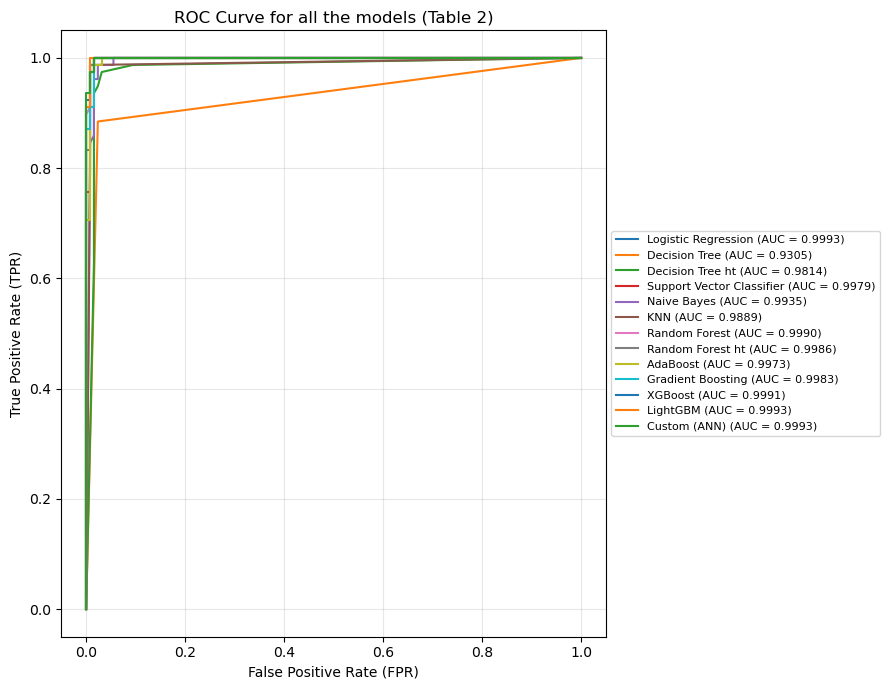

In [89]:
plt.figure(figsize=(9, 7))

for name, probs in models_probs.items():
    if name == 'XGBoost':
        fpr, tpr, _ = roc_curve(y_test_xgb, probs)
    else:
        fpr, tpr, _ = roc_curve(y_test_binary, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for all the models (Table 2)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/roc_curves_table2.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [90]:
models_probs = {
    'Logistic Regression': lr33.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree': dt33.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree ht': dt_ht33.predict_proba(X_test_scaled)[:, 1],
    'Support Vector Classifier': svc33.predict_proba(X_test_scaled)[:, 1],
    'Naive Bayes': nb33.predict_proba(X_test_scaled)[:, 1],
    'KNN': knn33.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf33.predict_proba(X_test_scaled)[:, 1],
    'Random Forest ht': rf_ht33.predict_proba(X_test_scaled)[:, 1],
    'AdaBoost': ada33.predict_proba(X_test_scaled)[:, 1],
    'Gradient Boosting': gb33.predict_proba(X_test_scaled)[:, 1],
    'XGBoost': xgb33.predict_proba(X_test_scaled)[:, 1],
    'LightGBM': lgbm33.predict_proba(X_test_scaled)[:, 1],
    'Custom (ANN)': ann.predict(X_test_scaled).flatten()
}

y_test_binary = y_test.map({2: 0, 4: 1})
xgb_probs = xgb33.predict_proba(X_test_scaled)[:, 1]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


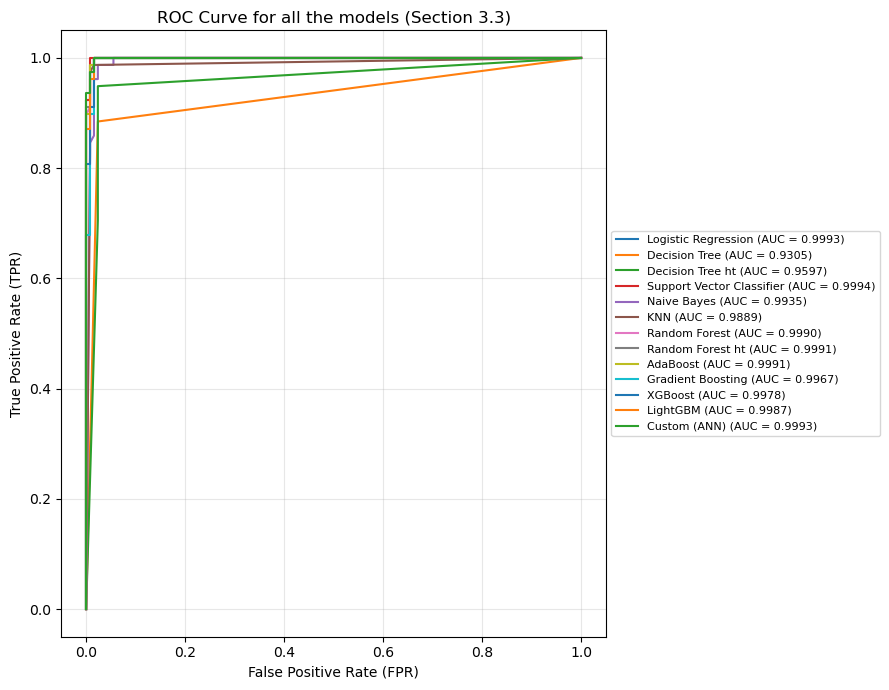

In [91]:
plt.figure(figsize=(9, 7))

for name, probs in models_probs.items():
    if name == 'XGBoost':
        fpr, tpr, _ = roc_curve(y_test_xgb, probs)
    else:
        fpr, tpr, _ = roc_curve(y_test_binary, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for all the models (Section 3.3)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "figures/roc_curves_section3.3.svg",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Observation:
The ROC curves remain similar to those obtained using Table 2 hyperparameters. The alternative hyperparameter configuration causes minor changes in AUC values but does not substantially alter the overall classification capability.